In [ ]:
!pip install -q sentence-transformers faiss-cpu pandas numpy scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 40.8 MB/s eta 0:00:00


In [ ]:
import json
import time
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

In [ ]:
!wget -q https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip
!unzip -qo scifact.zip

In [ ]:
corpus = {}
with open("scifact/corpus.jsonl", "r") as f:
    for line in f:
        doc = json.loads(line)
        corpus[str(doc["_id"])] = {
            "title": doc["title"],
            "text": doc["text"]
        }
print("Corpus documents:", len(corpus))

Corpus documents: 5183


In [ ]:
queries = {}
with open("scifact/queries.jsonl", "r") as f:
    for line in f:
        query = json.loads(line)
        queries[str(query["_id"])] = query["text"]
print("Queries:", len(queries))

Queries: 1109


In [ ]:
test_qrels_df = pd.read_csv(
    "scifact/qrels/test.tsv",sep="\t"
)
test_qrels_df["query-id"] = (test_qrels_df["query-id"].astype(str))
test_qrels_df["corpus-id"] = (test_qrels_df["corpus-id"].astype(str))
print("Test qrels:", len(test_qrels_df))

Test qrels: 339


In [ ]:
documents_df = pd.DataFrame([
    {
        "doc_id": doc_id,"title": doc["title"],"text": doc["text"]
    }
    for doc_id, doc in corpus.items()
])
documents_df["content"] = (
    documents_df["title"] +"\n\n" + documents_df["text"]
)
print("Documents:", len(documents_df))

Documents: 5183


In [ ]:
embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
print(
    "Embedding dimension:",embedding_model.get_sentence_embedding_dimension()
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


/tmp/ipykernel_4711/3297108931.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  "Embedding dimension:",embedding_model.get_sentence_embedding_dimension()


In [ ]:
document_embeddings = embedding_model.encode(
    documents_df["content"].tolist(),
    batch_size=32,show_progress_bar=True,normalize_embeddings=True
).astype("float32")
print(
    "Embedding matrix:",document_embeddings.shape
)

Batches:   0%|          | 0/162 [00:00<?, ?it/s]

Embedding matrix: (5183, 384)


In [ ]:
index = faiss.IndexFlatIP(document_embeddings.shape[1])
index.add(document_embeddings)
doc_id_mapping = documents_df["doc_id"].tolist()
print("FAISS index size:", index.ntotal)

FAISS index size: 5183


In [ ]:
from collections import defaultdict
qrels_lookup = defaultdict(set)
for _, row in test_qrels_df.iterrows():
    if row["score"] > 0:
        qrels_lookup[row["query-id"]].add(
            row["corpus-id"]
        )
print("Queries with relevance judgments:",len(qrels_lookup))

Queries with relevance judgments: 300


In [ ]:
def recall_at_k(
    retrieved_ids,relevant_ids,k
):
    relevant_ids = set(relevant_ids)
    if not relevant_ids:
        return 0.0
    retrieved = set(retrieved_ids[:k])
    return len(
        retrieved & relevant_ids
    ) / len(relevant_ids)
def reciprocal_rank(
    retrieved_ids,relevant_ids
):
    relevant_ids = set(relevant_ids)
    for rank, doc_id in enumerate(
        retrieved_ids,start=1
    ):
        if doc_id in relevant_ids:
            return 1 / rank
    return 0.0

In [ ]:
test_query_ids = list(qrels_lookup.keys())
test_query_texts = [
    queries[qid]
    for qid in test_query_ids
]
test_query_embeddings = embedding_model.encode(
    test_query_texts,batch_size=32,show_progress_bar=True,
    normalize_embeddings=True
).astype("float32")
scores, indices = index.search(
    test_query_embeddings,10
)
print(
    "Evaluated queries:",len(test_query_ids)
)

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluated queries: 300


In [ ]:
retrieval_results = []
for i, query_id in enumerate(test_query_ids):
    retrieved_ids = [
        doc_id_mapping[idx]
        for idx in indices[i]
    ]
    relevant_ids = qrels_lookup[query_id]
    retrieval_results.append({
        "query_id": query_id,
        "recall@1": recall_at_k(
            retrieved_ids,relevant_ids,1
        ),
        "recall@5": recall_at_k(
            retrieved_ids,relevant_ids,5
        ),
        "recall@10": recall_at_k(
            retrieved_ids,relevant_ids,10
        ),
        "MRR": reciprocal_rank(
            retrieved_ids,relevant_ids
        )
    })

In [ ]:
retrieval_metrics_df = pd.DataFrame(retrieval_results)
retrieval_summary = pd.DataFrame({
    "Metric": [
        "Recall@1","Recall@5","Recall@10","MRR"
    ],
    "Score": [
        retrieval_metrics_df["recall@1"].mean(),
        retrieval_metrics_df["recall@5"].mean(),
        retrieval_metrics_df["recall@10"].mean(),
        retrieval_metrics_df["MRR"].mean()
    ]
})
retrieval_summary

,Metric,Score
0,Recall@1,0.482333
1,Recall@5,0.737944
2,Recall@10,0.783333
3,MRR,0.604725


In [ ]:
import pandas as pd
benchmark_df = pd.read_csv("/content/model_routing_benchmark.csv")
benchmark_summary = pd.read_csv("/content/model_routing_benchmark_summary.csv")
end_to_end_df = pd.read_csv("/content/cost_aware_rag_end_to_end.csv")
print("Benchmark queries:", len(benchmark_df))
print("End-to-end requests:", len(end_to_end_df))

Benchmark queries: 20
End-to-end requests: 20


In [ ]:
benchmark_df = pd.read_csv("model_routing_benchmark.csv")
benchmark_summary = pd.read_csv("model_routing_benchmark_summary.csv")
print("Benchmark loaded successfully.")
print("Benchmark queries:", len(benchmark_df))
benchmark_df.head()

Benchmark loaded successfully.
Benchmark queries: 20


,query,large_input_tokens,large_output_tokens,large_total_tokens,large_latency_sec,large_cost,large_answer,small_input_tokens,small_output_tokens,small_total_tokens,small_latency_sec,small_cost,small_answer
0,0-dimensional biomaterials lack inductive prop...,947,142,1089,0.831071,0.000227,The provided documents do not contain informat...,947,157,1104,0.641116,0.000118,The provided context does not contain informat...
1,1 in 5 million in UK have abnormal PrP positiv...,2308,303,2611,1.388979,0.000528,The statement is not supported by the data. In...,2308,263,2571,0.847703,0.000252,The data from the large‑scale appendix survey ...
2,1-1% of colorectal cancer patients are diagnos...,1945,310,2255,1.200968,0.000478,The documents do not support the claim that on...,1945,259,2204,0.806679,0.000224,No. In the Dutch nationwide study (1996‑2011) ...
3,10% of sudden infant death syndrome (SIDS) dea...,1928,268,2196,1.144945,0.000450,The provided documents do not contain any data...,1928,201,2129,0.750483,0.000205,"I’m sorry, but the provided documents do not c..."
4,32% of liver transplantation programs required...,1651,346,1997,10.329811,0.000455,The provided documents state that 32 percent o...,1651,272,1923,0.896797,0.000205,"Yes. According to the study, 32 % of liver‑tra..."


In [ ]:
model_cost_summary = pd.DataFrame({
    "Metric": [
        "Average input tokens",
        "Average output tokens",
        "Average total tokens",
        "Average latency (sec)",
        "Average estimated cost"
    ],
    "GPT-OSS-20B": [
        benchmark_df["small_input_tokens"].mean(),
        benchmark_df["small_output_tokens"].mean(),
        benchmark_df["small_total_tokens"].mean(),
        benchmark_df["small_latency_sec"].mean(),
        benchmark_df["small_cost"].mean()
    ],
    "GPT-OSS-120B": [
        benchmark_df["large_input_tokens"].mean(),
        benchmark_df["large_output_tokens"].mean(),
        benchmark_df["large_total_tokens"].mean(),
        benchmark_df["large_latency_sec"].mean(),
        benchmark_df["large_cost"].mean()
    ]
})
model_cost_summary

,Metric,GPT-OSS-20B,GPT-OSS-120B
0,Average input tokens,1911.850000,1911.850000
1,Average output tokens,232.900000,234.050000
2,Average total tokens,2144.750000,2145.900000
3,Average latency (sec),0.848552,12.358472
4,Average estimated cost,0.000213,0.000427


In [ ]:
answer_embeddings_small = embedding_model.encode(
    benchmark_df["small_answer"].tolist(),batch_size=16,
    normalize_embeddings=True).astype("float32")
answer_embeddings_large = embedding_model.encode(
    benchmark_df["large_answer"].tolist(),batch_size=16,
    normalize_embeddings=True).astype("float32")

In [ ]:
answer_similarity = np.sum(
    answer_embeddings_small *answer_embeddings_large,axis=1
)
benchmark_df["answer_similarity"] = (answer_similarity)
print(
    benchmark_df["answer_similarity"].describe()
)

count    20.000000
mean      0.867138
std       0.097629
min       0.635374
25%       0.860447
50%       0.896867
75%       0.921866
max       0.975927
Name: answer_similarity, dtype: float64


In [ ]:
evaluation_summary = pd.DataFrame({
    "System": [
        "GPT-OSS-20B","GPT-OSS-120B"
    ],
    "Average Cost": [
        benchmark_df["small_cost"].mean(),benchmark_df["large_cost"].mean()
    ],
    "Average Latency": [
        benchmark_df["small_latency_sec"].mean(),benchmark_df["large_latency_sec"].mean()
    ],
    "Average Tokens": [
        benchmark_df["small_total_tokens"].mean(),benchmark_df["large_total_tokens"].mean()
    ]
})
evaluation_summary

,System,Average Cost,Average Latency,Average Tokens
0,GPT-OSS-20B,0.000213,0.848552,2144.75
1,GPT-OSS-120B,0.000427,12.358472,2145.90


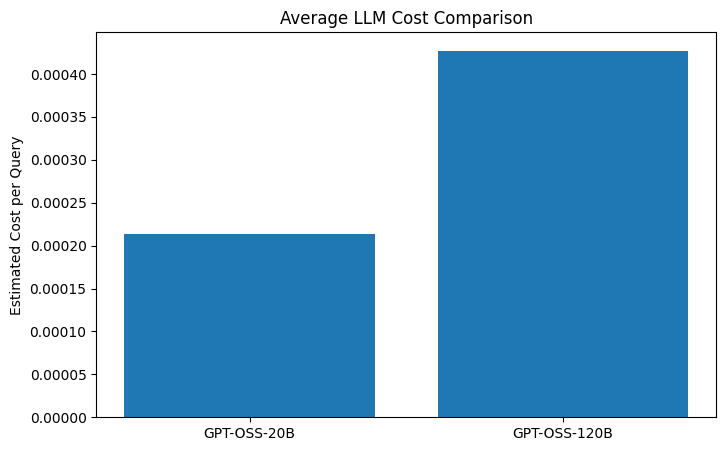

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    evaluation_summary["System"],evaluation_summary["Average Cost"]
)
plt.ylabel("Estimated Cost per Query")
plt.title("Average LLM Cost Comparison")
plt.show()

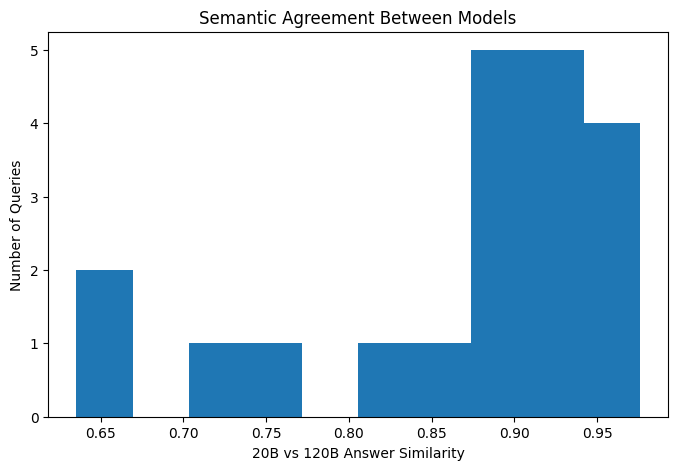

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(
    benchmark_df["answer_similarity"],bins=10
)
plt.xlabel("20B vs 120B Answer Similarity")
plt.ylabel("Number of Queries")
plt.title("Semantic Agreement Between Models")
plt.show()

In [ ]:
end_to_end_df = pd.read_csv("cost_aware_rag_end_to_end.csv")
print("End-to-end requests:",len(end_to_end_df))
end_to_end_df.head()

End-to-end requests: 20


,query,cache_hit,cache_similarity,cached_query,selected_model,answer,input_tokens,output_tokens,total_tokens,estimated_cost,latency_sec
0,0-dimensional biomaterials lack inductive prop...,False,NaN,NaN,openai/gpt-oss-20b,The provided context does not contain informat...,947,157,1104,0.000118,0.747941
1,1 in 5 million in UK have abnormal PrP positiv...,False,NaN,NaN,openai/gpt-oss-120b,The documents do not support a prevalence as l...,2308,299,2607,0.000526,1.385368
2,1-1% of colorectal cancer patients are diagnos...,False,NaN,NaN,openai/gpt-oss-120b,The documents do not support that only 1 % of ...,1945,265,2210,0.000451,1.283849
3,10% of sudden infant death syndrome (SIDS) dea...,False,NaN,NaN,openai/gpt-oss-20b,"I’m sorry, but the provided documents do not c...",1928,206,2134,0.000206,0.937301
4,32% of liver transplantation programs required...,False,NaN,NaN,openai/gpt-oss-120b,The provided document notes that **32 % of liv...,1651,363,2014,0.000465,1.426188


In [ ]:
total_requests = len(end_to_end_df)
cache_hits = int(end_to_end_df["cache_hit"].sum())
cache_hit_rate = (cache_hits /total_requests) * 100
llm_calls = (total_requests -cache_hits)
print("Total requests:",total_requests)
print("Cache hits:",cache_hits)
print("Cache hit rate:",round(cache_hit_rate, 2),"%")
print("LLM calls:",llm_calls)

Total requests: 20
Cache hits: 11
Cache hit rate: 55.0 %
LLM calls: 9


In [ ]:
model_distribution = (end_to_end_df[~end_to_end_df["cache_hit"]
    ]["selected_model"].value_counts()
)
model_distribution

,count
selected_model,
openai/gpt-oss-120b,5
openai/gpt-oss-20b,4


In [ ]:
workload_queries = (benchmark_df["query"].iloc[:10].tolist() * 2)
print("Total requests:", len(workload_queries))
print("Unique queries:", len(set(workload_queries)))

Total requests: 20
Unique queries: 10


In [ ]:
actual_system_cost = (
    end_to_end_df["estimated_cost"].sum()
)
baseline_120b_cost = (
    benchmark_df[benchmark_df["query"].isin(workload_queries)
    ]["large_cost"].sum()) * 2
cost_saved = (
    baseline_120b_cost - actual_system_cost
)
cost_reduction = (
    cost_saved / baseline_120b_cost
) * 100
final_cost_comparison = pd.DataFrame({
    "System": [
        "Always GPT-OSS-120B","Cache + Intelligent Router"
    ],
    "Total Estimated Cost": [
        baseline_120b_cost,actual_system_cost
    ]
})
final_cost_comparison[
    "Cost Reduction (%)"
] = (
    1 -final_cost_comparison["Total Estimated Cost"] /baseline_120b_cost
) * 100
final_cost_comparison

,System,Total Estimated Cost,Cost Reduction (%)
0,Always GPT-OSS-120B,0.008408,0.000000
1,Cache + Intelligent Router,0.003025,64.026261


In [ ]:
final_metrics = {
    "retrieval_recall@1":
        retrieval_summary.loc[
            retrieval_summary["Metric"] == "Recall@1","Score"
        ].iloc[0],
    "retrieval_recall@5":
        retrieval_summary.loc[
            retrieval_summary["Metric"] == "Recall@5","Score"
        ].iloc[0],
    "retrieval_recall@10":
        retrieval_summary.loc[
            retrieval_summary["Metric"] == "Recall@10","Score"
        ].iloc[0],
    "retrieval_MRR":
        retrieval_summary.loc[
            retrieval_summary["Metric"] == "MRR","Score"
        ].iloc[0],
    "cache_hit_rate_pct":
        cache_hit_rate,
    "llm_calls":llm_calls,
    "total_requests":total_requests,
    "baseline_120b_cost":baseline_120b_cost,
    "system_cost":actual_system_cost,
    "cost_reduction_pct":cost_reduction,
    "average_answer_similarity":
        benchmark_df["answer_similarity"].mean()
}
final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.T

,0
retrieval_recall@1,0.482333
retrieval_recall@5,0.737944
retrieval_recall@10,0.783333
retrieval_MRR,0.604725
cache_hit_rate_pct,55.000000
llm_calls,9.000000
total_requests,20.000000
baseline_120b_cost,0.008408
system_cost,0.003025
cost_reduction_pct,64.026261


In [ ]:
retrieval_summary.to_csv("final_retrieval_metrics.csv",index=False)
model_cost_summary.to_csv("final_model_cost_comparison.csv",index=False)
final_cost_comparison.to_csv("final_cost_comparison.csv",index=False)
final_metrics_df.to_csv("final_evaluation_metrics.csv",index=False)
print("All evaluation results saved.")

All evaluation results saved.


In [ ]:
benchmark_cost_lookup = (
    benchmark_df.set_index("query")["large_cost"].to_dict()
)
workload_baseline_costs = [
    benchmark_cost_lookup[query]
    for query in workload_queries
]
corrected_baseline_120b_cost = sum(workload_baseline_costs)
actual_system_cost = (end_to_end_df["estimated_cost"].sum())
corrected_cost_saved = (
    corrected_baseline_120b_cost -actual_system_cost
)
corrected_cost_reduction = (
    corrected_cost_saved / corrected_baseline_120b_cost
) * 100
print("Corrected 120B-only baseline cost: $",
    round(corrected_baseline_120b_cost, 6)
)
print("Cache + Router cost: $",round(actual_system_cost, 6))
print("Corrected cost saved: $",round(corrected_cost_saved, 6))
print("Corrected cost reduction:",round(corrected_cost_reduction, 2),"%")

Corrected 120B-only baseline cost: $ 0.008408
Cache + Router cost: $ 0.003025
Corrected cost saved: $ 0.005383
Corrected cost reduction: 64.03 %


In [ ]:
print("Total requests:",len(end_to_end_df))
print("Cache hits:",int(end_to_end_df["cache_hit"].sum()))
print("LLM calls:",int((~end_to_end_df["cache_hit"]).sum()))
print("\nModel usage on cache misses:")
print(end_to_end_df[~end_to_end_df["cache_hit"]]["selected_model"].value_counts())

Total requests: 20
Cache hits: 11
LLM calls: 9

Model usage on cache misses:
selected_model
openai/gpt-oss-120b    5
openai/gpt-oss-20b     4
Name: count, dtype: int64
